# Trabalho de séries temporais - Pipeline completa para uma serie temporal não estacionária

In [8]:
import warnings
warnings.filterwarnings("ignore")

## Carregando a base

In [9]:

import kagglehub

path_brazil = kagglehub.dataset_download("azminetoushikwasi/brazil-all-international-matches-19142023")

print("Path to dataset files:", path_brazil)

Path to dataset files: C:\Users\miguelaraujo-ieg\.cache\kagglehub\datasets\azminetoushikwasi\brazil-all-international-matches-19142023\versions\4


In [10]:
import pandas as pd
import os
df_brazil = pd.read_csv(os.path.join(path_brazil, "brazil.csv"))

In [11]:
df_brazil

,Date,Match,Result,Score,Competition
0,20 Sep 1914,Argentina v Brazil,L,3-0,International Friendly
1,27 Sep 1914,Argentina v Brazil,W,0-1,Copa Julio Roca
2,08 Jul 1916,Chile v Brazil,D,1-1,Copa America
3,10 Jul 1916,Argentina v Brazil,D,1-1,Copa America
4,12 Jul 1916,Uruguay v Brazil,L,2-1,Copa America
...,...,...,...,...,...
1029,24 Nov 2022,Brazil v Serbia,W,2-0,FIFA World Cup
1030,28 Nov 2022,Brazil v Switzerland,W,1-0,FIFA World Cup
1031,02 Dec 2022,Cameroon v Brazil,L,1-0,FIFA World Cup
1032,05 Dec 2022,Brazil v Korea Republic,W,4-1,FIFA World Cup


## Fazendo limpeza da base

In [12]:
df_brazil = df_brazil.dropna(subset=['Date', 'Result'])
df_brazil

,Date,Match,Result,Score,Competition
0,20 Sep 1914,Argentina v Brazil,L,3-0,International Friendly
1,27 Sep 1914,Argentina v Brazil,W,0-1,Copa Julio Roca
2,08 Jul 1916,Chile v Brazil,D,1-1,Copa America
3,10 Jul 1916,Argentina v Brazil,D,1-1,Copa America
4,12 Jul 1916,Uruguay v Brazil,L,2-1,Copa America
...,...,...,...,...,...
1029,24 Nov 2022,Brazil v Serbia,W,2-0,FIFA World Cup
1030,28 Nov 2022,Brazil v Switzerland,W,1-0,FIFA World Cup
1031,02 Dec 2022,Cameroon v Brazil,L,1-0,FIFA World Cup
1032,05 Dec 2022,Brazil v Korea Republic,W,4-1,FIFA World Cup


#### Colunas específicas

In [13]:
df_brazil = df_brazil[['Date', 'Result']]
df_brazil

,Date,Result
0,20 Sep 1914,L
1,27 Sep 1914,W
2,08 Jul 1916,D
3,10 Jul 1916,D
4,12 Jul 1916,L
...,...,...
1029,24 Nov 2022,W
1030,28 Nov 2022,W
1031,02 Dec 2022,L
1032,05 Dec 2022,W


#### Transformando coluna de data em formato amigável

In [14]:
df_brazil['Date'] = pd.to_datetime(df_brazil['Date'], format='%d %b %Y')
df_brazil

,Date,Result
0,1914-09-20,L
1,1914-09-27,W
2,1916-07-08,D
3,1916-07-10,D
4,1916-07-12,L
...,...,...
1029,2022-11-24,W
1030,2022-11-28,W
1031,2022-12-02,L
1032,2022-12-05,W


#### Criando regra de negócio da serie temporal

In [ ]:
df_brazil['win'] = (df_brazil['Result'] == 'W').astype(int)

df_brazil['year'] = df_brazil['Date'].dt.year

sr_brazil = df_brazil.groupby('year')['win'].sum()
sr_brazil

year
1914     1
1916     2
1917     1
1919     3
1920     1
        ..
2018    13
2019     9
2020     4
2021    12
2022    10
Name: win, Length: 97, dtype: int64

#### Plot das series

In [18]:
from matplotlib import pyplot as plt
def plot_serie(serie):
    fig, ax = plt.subplots()
    ax.plot(serie)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)    
    plt.tight_layout()
    plt.show()

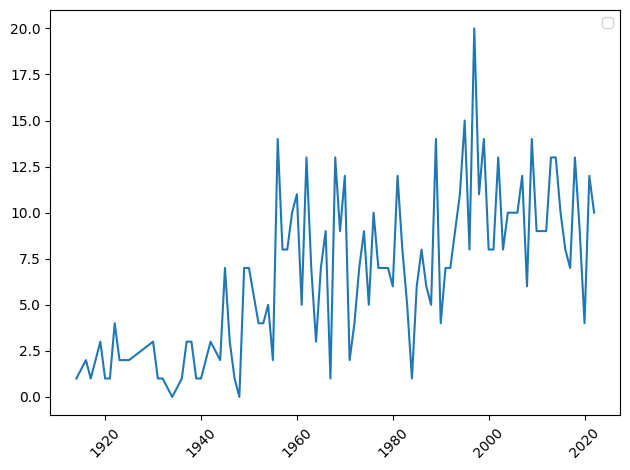

In [19]:
plot_serie(sr_brazil)  

## Fazendo os testes na série - ACF e PACF, Sazonalidade, ADF e KPSS

#### Fazendo metodo de autocorrelação e autocorrelação parcial

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(serie):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    plot_acf(serie, ax=axes[0])
    plot_pacf(serie, ax=axes[1])
    plt.show()

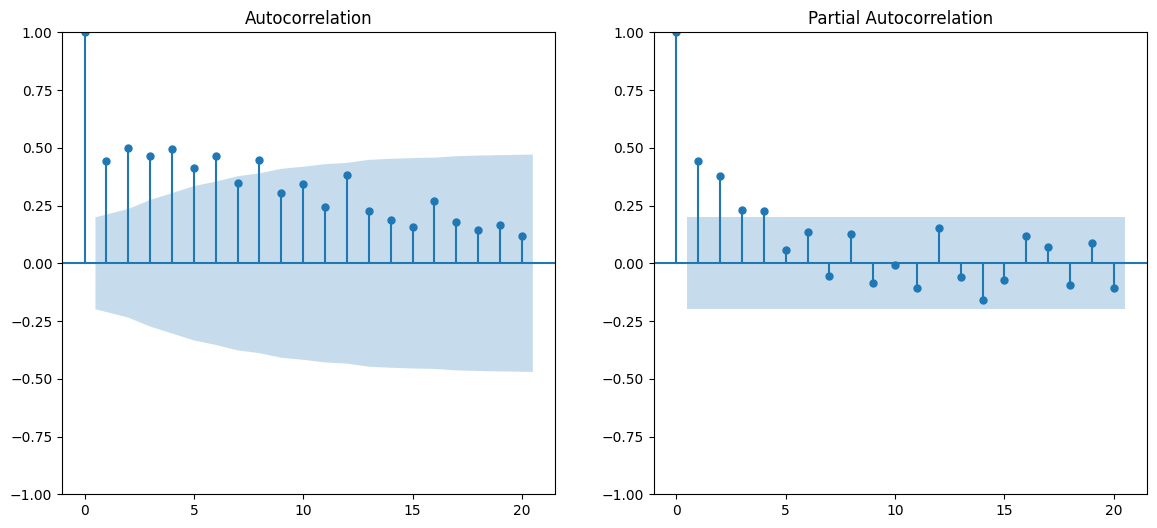

In [21]:
plot_acf_pacf(sr_brazil)

#### Fazendo teste de força sazonal para verificar a sazonalidade da série

In [34]:
from statsmodels.tsa.seasonal import STL
import numpy as np
import matplotlib.pyplot as plt

valores_m = range(2, 31)

forcas = []

for m in valores_m:
    try:
        stl = STL(sr_brazil, period=m, robust=True).fit()

        forca = 1 - (
            np.var(stl.resid) /
            np.var(stl.seasonal + stl.resid)
        )

        forcas.append(forca)

    except Exception as e:
        print(f'Erro em m = {m}: {e}')

media_forca = np.mean(forcas)
maior_forca = max(forcas)

print('\n-----------------------------------')
print(f'Média da força da sazonalidade: {media_forca:.5f}')
print(f'Maior força da sazonalidade: {maior_forca:.5f} no periodo {valores_m[forcas.index(maior_forca)]}')
print('-----------------------------------')


-----------------------------------
Média da força da sazonalidade: 0.15918
Maior força da sazonalidade: 0.46058 no periodo 29
-----------------------------------


### A SÉRIE NÃO É SAZONAL

#### Fazendo os metodos estatísticos de estacionariedade

In [22]:
from statsmodels.tsa.stattools import adfuller, kpss
def teste_adf(serie, nome):
    resultado = adfuller(serie, autolag='AIC')
    p_valor = resultado[1]
    conclusao = 'ESTACIONÁRIA' if p_valor < 0.05 else 'NÃO ESTACIONÁRIA'
    
    print(f'\n=== Teste ADF — {nome} ===')
    print(f'  Estatística ADF: {resultado[0]:.4f}')
    print(f'  p-value:         {p_valor:.6f}')
    print(f'  Lags usados:     {resultado[2]}')
    print(f'  Observações:     {resultado[3]}')
    for key, val in resultado[4].items():
        print(f'  Valor crítico {key}: {val:.4f}')
    print(f'  → Conclusão ADF: {conclusao}')
    return p_valor

def teste_kpss(serie, nome):
    resultado = kpss(serie, regression='c', nlags='auto')
    p_valor = resultado[1]
    conclusao = 'ESTACIONÁRIA' if p_valor >= 0.05 else 'NÃO ESTACIONÁRIA'
    
    print(f'\n=== Teste KPSS — {nome} ===')
    print(f'  Estatística KPSS: {resultado[0]:.4f}')
    print(f'  p-value:          {p_valor:.4f}')
    print(f'  Lags usados:      {resultado[2]}')
    for key, val in resultado[3].items():
        print(f'  Valor crítico {key}: {val:.4f}')
    print(f'  → Conclusão KPSS: {conclusao}')
    return p_valor

def analise_estacionariedade(serie, nome):
    p_adf = teste_adf(serie, nome)
    p_kpss = teste_kpss(serie, nome)
    
    print(f'\n--- Conclusão combinada para "{nome}" ---')
    if p_adf < 0.05 and p_kpss >= 0.05:
        print('Ambos os testes concordam: ESTACIONÁRIA')
    elif p_adf >= 0.05 and p_kpss < 0.05:
        print(' Ambos os testes concordam: NÃO ESTACIONÁRIA')
    print('=' * 50)

In [23]:
analise_estacionariedade(sr_brazil, 'Série de vitorias do Brasil')


=== Teste ADF — Série de vitorias do Brasil ===
  Estatística ADF: -2.0557
  p-value:         0.262685
  Lags usados:     3
  Observações:     93
  Valor crítico 1%: -3.5027
  Valor crítico 5%: -2.8932
  Valor crítico 10%: -2.5836
  → Conclusão ADF: NÃO ESTACIONÁRIA

=== Teste KPSS — Série de vitorias do Brasil ===
  Estatística KPSS: 1.3068
  p-value:          0.0100
  Lags usados:      5
  Valor crítico 10%: 0.3470
  Valor crítico 5%: 0.4630
  Valor crítico 2.5%: 0.5740
  Valor crítico 1%: 0.7390
  → Conclusão KPSS: NÃO ESTACIONÁRIA

--- Conclusão combinada para "Série de vitorias do Brasil" ---
 Ambos os testes concordam: NÃO ESTACIONÁRIA


C:\Users\miguelaraujo-ieg\AppData\Local\Temp\ipykernel_18488\3872084422.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado = kpss(serie, regression='c', nlags='auto')


### A SÉRIE É NÃO ESTACIONÁRIA

## Fazendo modelo SARIMA